# Full Model: Figures 2 And 3

This notebook reproduces the full-transformer attention and KL-divergence plots in report Figures 2 and 3. The run is the `ICLR-full` / `ICLR-dataset` W&B run `dbrr8opu`.


In [1]:
from analysis.utils import fetch_run_data, plot_combined_heads, plot_kl_divergence_simple, report_head_color_map
import pandas as pd


SAVE_FIGURES = False


def output_path(name):
    return f"analysis/figures/{name}" if SAVE_FIGURES else None


In [2]:
RUN_ID = "dbrr8opu"
ATTENTION_STEPS = [0, 60, 300, 1000]
DIVERGENCE_STEPS = [2065, 2450]
MAX_STEPS = 3000

run_data = fetch_run_data(RUN_ID, metrics=["val_loss"])
cfg = run_data["config"]
pd.DataFrame(
    [
        {
            "run_id": RUN_ID,
            "name": run_data["name"],
            "tags": "ICLR-full, ICLR-dataset",
            "blocks": cfg["student"]["num_blocks"],
            "heads": cfg["student"]["num_heads"],
            "architecture": "full transformer",
            "span_lengths": cfg["teacher"]["span_lengths"],
        }
    ]
)


,run_id,name,tags,blocks,heads,architecture,span_lengths
0,dbrr8opu,jumping-haze-1689,"ICLR-full, ICLR-dataset",1,3,full transformer,"[4, 4, 4]"


## Figure 2: Attention Patterns

The four panels show the sum of learned attention patterns as training moves from uniform attention to competitive copying and then to head specialization.


wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


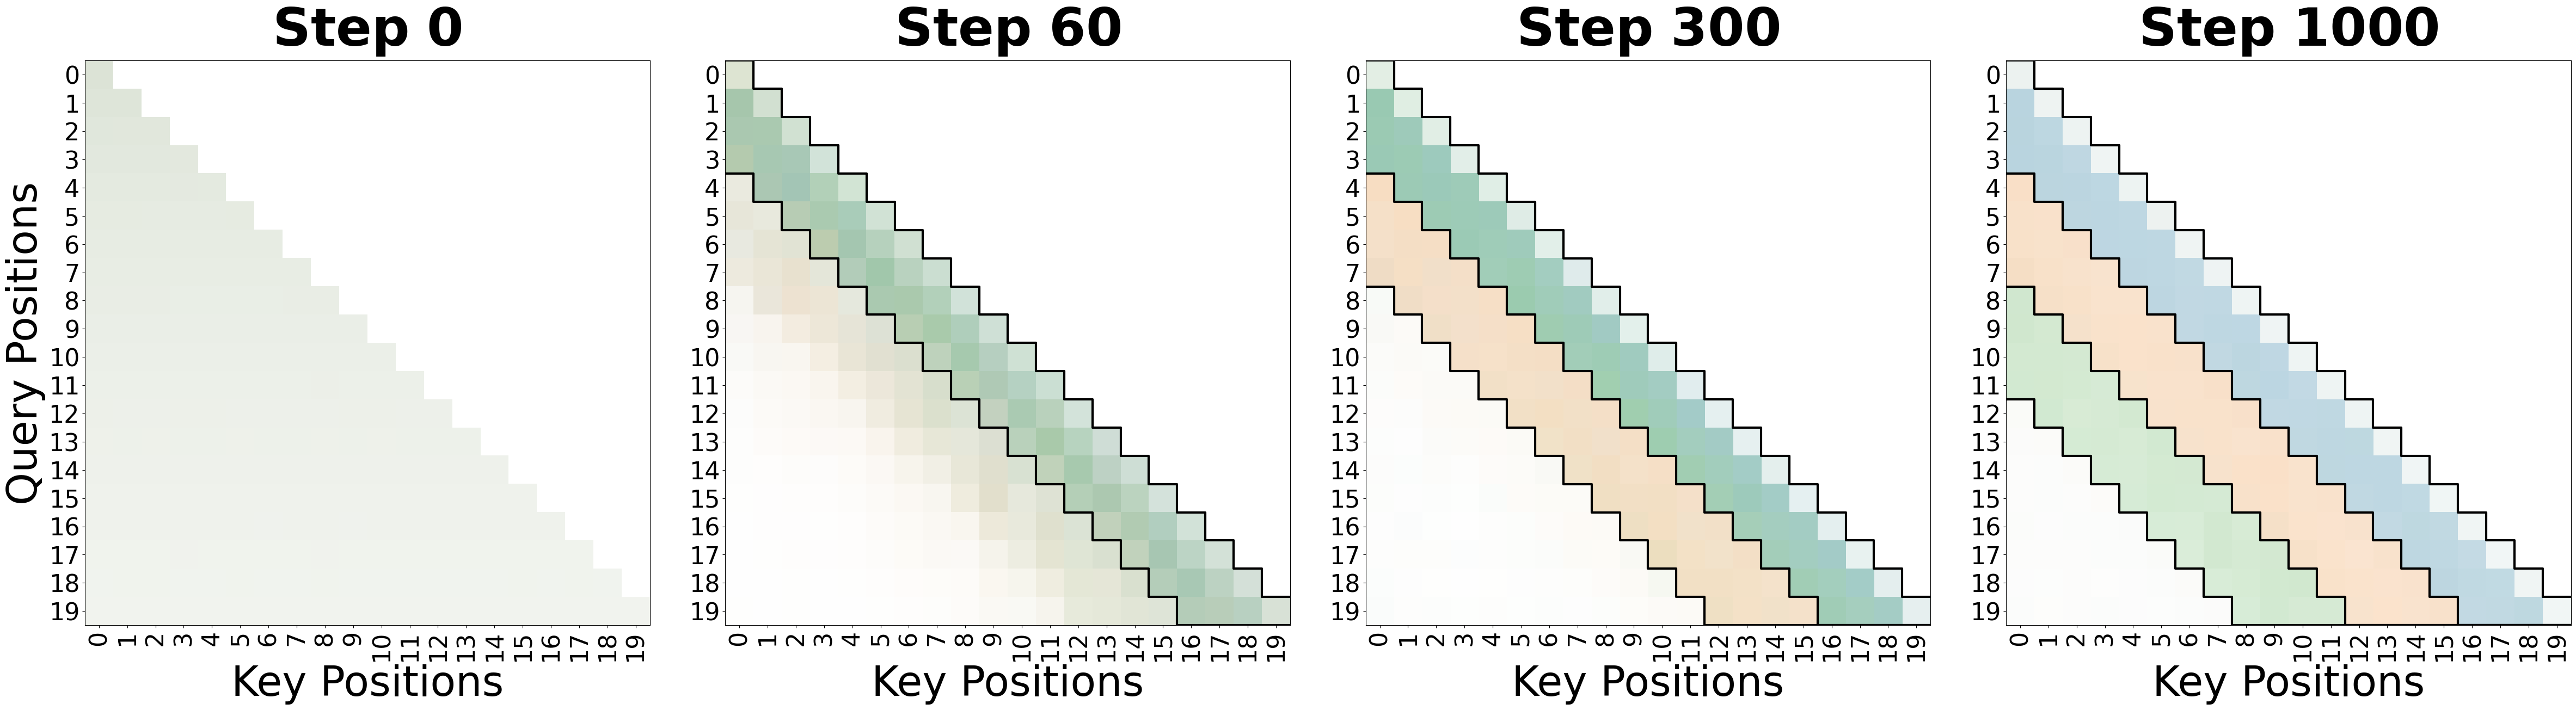

In [3]:
plot_combined_heads(
    RUN_ID,
    steps=ATTENTION_STEPS,
    split="val",
    head_colors=report_head_color_map([1, 0, 2]),
    staircases={1: [0, -4], 2: [0, -4, -8], 3: [0, -4, -8, -12]},
    save_name=output_path("full-model-attention"),
)


## Figure 3: KL Divergence

The first plot compares the transformer to the ideal predictors that use one, two, or three feature groups. The second uses learned restricted-context baselines, matching the report's restricted-context comparison.


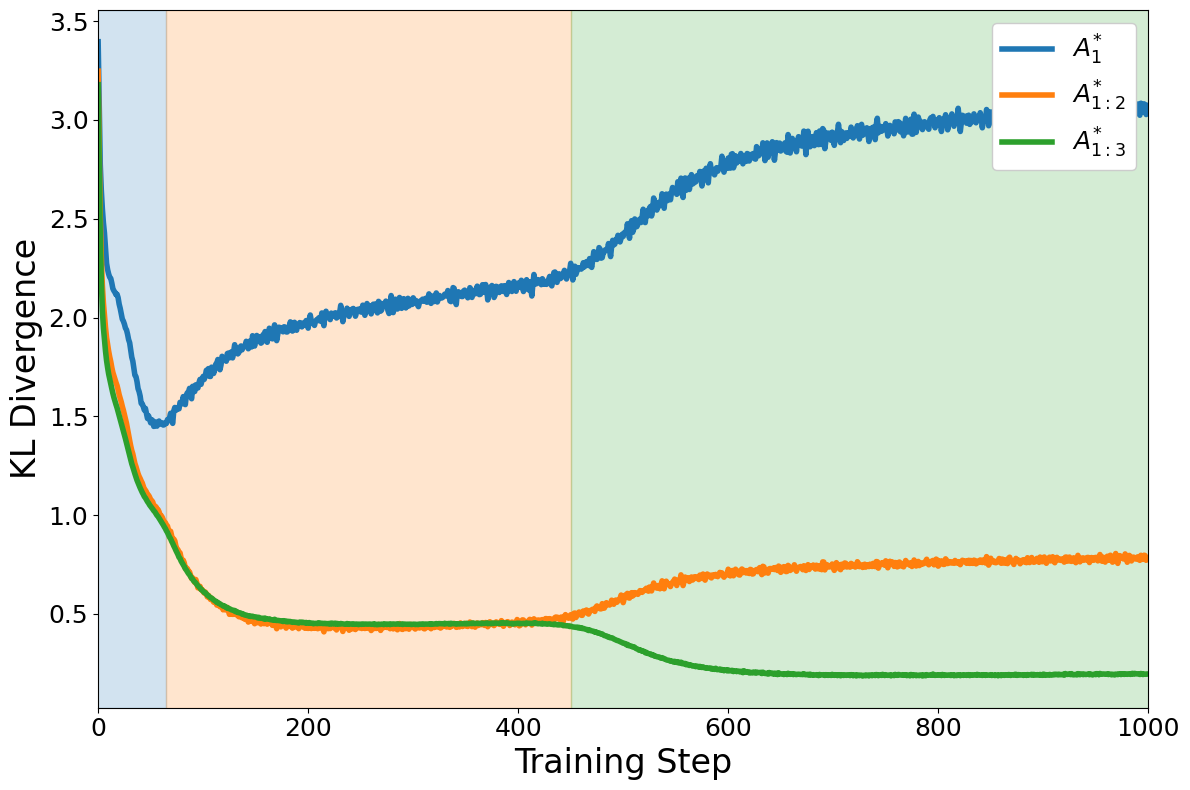

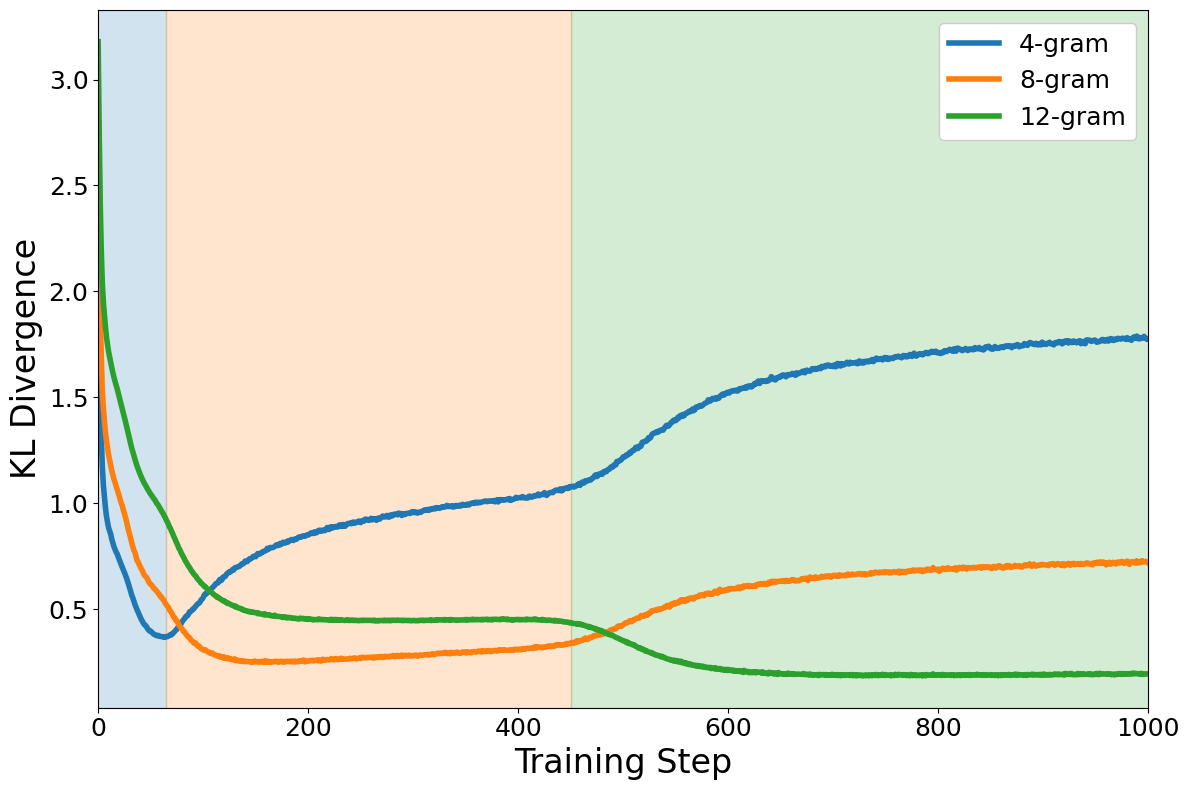

In [4]:
plot_kl_divergence_simple(
    run_id=RUN_ID,
    divergence_steps=DIVERGENCE_STEPS,
    max_steps=MAX_STEPS,
    figsize=(12, 8),
    learnable=False,
    shift_steps=True,
    save_name=output_path("full-model-kl-prefix"),
)

plot_kl_divergence_simple(
    run_id=RUN_ID,
    divergence_steps=DIVERGENCE_STEPS,
    max_steps=MAX_STEPS,
    figsize=(12, 8),
    learnable=True,
    shift_steps=True,
    save_name=output_path("full-model-kl-learned"),
)
